In [1]:
import pandas as pd


In [4]:
# df = pd.read_csv("../data/raw/events.csv")
df = pd.read_csv("../data/raw/events.csv", nrows=500000)

In [5]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     500000 non-null  str    
 1   event_type     500000 non-null  str    
 2   product_id     500000 non-null  int64  
 3   category_id    500000 non-null  int64  
 4   category_code  337628 non-null  str    
 5   brand          425209 non-null  str    
 6   price          500000 non-null  float64
 7   user_id        500000 non-null  int64  
 8   user_session   500000 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 34.3 MB


In [7]:
df['event_type'].unique()

<StringArray>
['view', 'cart', 'purchase']
Length: 3, dtype: str

In [ ]:
df['user_id'].nunique()

3696117

In [8]:
len(df)

500000

In [9]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     500000 non-null  datetime64[us, UTC]
 1   event_type     500000 non-null  str                
 2   product_id     500000 non-null  int64              
 3   category_id    500000 non-null  int64              
 4   category_code  337628 non-null  str                
 5   brand          425209 non-null  str                
 6   price          500000 non-null  float64            
 7   user_id        500000 non-null  int64              
 8   user_session   500000 non-null  str                
dtypes: datetime64[us, UTC](1), float64(1), int64(3), str(4)
memory usage: 34.3 MB


In [12]:
df.isna().sum()


event_time            0
event_type            0
product_id            0
category_id           0
category_code    162372
brand             74791
price                 0
user_id               0
user_session          0
dtype: int64

In [13]:
df.isna().mean()

event_time       0.000000
event_type       0.000000
product_id       0.000000
category_id      0.000000
category_code    0.324744
brand            0.149582
price            0.000000
user_id          0.000000
user_session     0.000000
dtype: float64

In [14]:
df['event_type'].value_counts()

event_type
view        482642
purchase      9595
cart          7763
Name: count, dtype: int64

In [ ]:
# df_sample = df.sample(500000,random_state=42) #random_state=42 ensures the split is the same every time you run the code,
#which is handy for reproducibility. You can use any integer in random_state , 42 

In [15]:
df = df.sort_values(['event_time'])

In [16]:
df['event_type'].value_counts()

event_type
view        482642
purchase      9595
cart          7763
Name: count, dtype: int64

In [17]:
df['user_session'].nunique()

121783

In [18]:
df['user_id'].nunique()

92750

In [ ]:
# We understood that:some users have multiple sessions and some sessions have multiple events.

# How many sessions resulted in a purchase?
# # ie. conversion rate = sessions with purchase / total sessions
# Understand the diff between session and event.
# So conversion metrics are usually:conversion per session NOT conversion per event

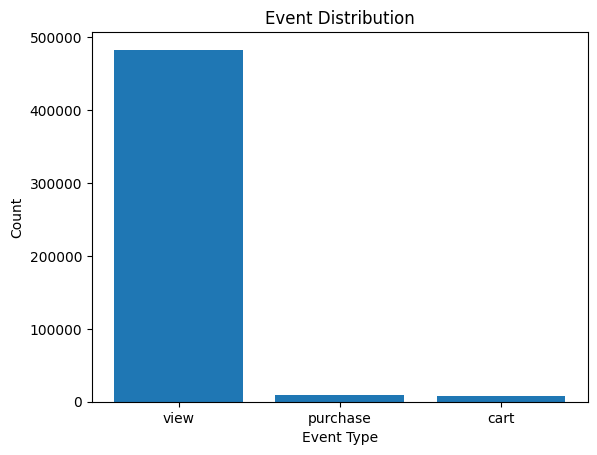

In [19]:
import matplotlib.pyplot as plt

events = df['event_type'].value_counts()

plt.bar(events.index, events.values)
plt.title("Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

In [21]:
funnel = df.groupby('event_type')['user_id'].nunique()
# # We count distinct users in each group. Users who added to cat, purchased, viewed!!!
# unique users who viewed
# unique users who carted
# unique users who purchased
funnel

event_type
cart         4501
purchase     7389
view        92743
Name: user_id, dtype: int64

A funnel requires sequential behavior:
View → Cart → Purchase
But raw event data may contain sessions like:
Session A: view
Session B: purchase
Session C: view → cart
Session D: purchase

The Big Lesson: You just discovered a very real analytics problem: Event-level sampling can break funnels
Good analysts think about:
What is the unit of analysis?
Events?
Sessions?
Users?


sessions that viewed AND carted, sessions that carted AND purchased (using intersection operator)
This concept is called: sequential funnel filtering.
When we did: df_sample = df.sample(500000), this means random events from the dataset. Not random sessions.

In [ ]:

# # note we're counting sessions NOT users
# # companies measure user purchases AND session cnversions
# session conversion alone doesn't tell us where the problem is.
# Are people not adding to cart?
# Are they abandoning checkout?
# view_sessions = df[df['event_type']=='view']['user_session'].nunique()

# cart_sessions = df[df['event_type']=='cart']['user_session'].nunique()

# purchase_sessions = df[df['event_type']=='purchase']['user_session'].nunique()

# view_to_cart_session = cart_sessions / view_sessions
# cart_to_purchase_session = purchase_sessions / cart_sessions
# view_to_purchase_session = purchase_sessions / view_sessions

In [ ]:
# Each variable is a set of session IDs. AND using set: Duplicates removed automatically.
view_sessions = set(df[df['event_type']=='view']['user_session'])
cart_sessions = set(df[df['event_type']=='cart']['user_session'])
purchase_sessions = set(df[df['event_type']=='purchase']['user_session'])


# These are sessions that had BOTH events.

view_cart_sessions = view_sessions & cart_sessions
cart_purchase_sessions = cart_sessions & purchase_sessions
view_purchase_session = purchase_sessions & view_sessions

view_to_cart_session = len(view_cart_sessions) / len(view_sessions)

cart_to_purchase_session = len(cart_purchase_sessions) / len(cart_sessions)

view_to_purchase_session = len(view_purchase_session) / len(view_sessions)

In [39]:
# cart_abandonment = (cart_sessions - purchase_sessions) / cart_sessions
cart_abandonment = 1 - (len(cart_purchase_sessions) / len(cart_sessions))

In [41]:
print('view_to_cart_session:', view_to_cart_session)
print('cart_to_purchase_session', cart_to_purchase_session)
print('view_to_purchase_session', view_to_purchase_session)
print('cart_abandonment:', cart_abandonment)

view_to_cart_session: 0.0414719290319931
cart_to_purchase_session 0.5675782018493016
view_to_purchase_session 0.06830670664092982
cart_abandonment: 0.43242179815069837


In [25]:
total_sessions= df['user_session'].nunique()

In [42]:
# Out of all visits (sessions) to the website,
# # what percentage resulted in a purchase?
# This is the primary top-level conversion KPI used in growth analytics.
conversion_rate = len(purchase_sessions) / total_sessions
print('conversion_rate:', conversion_rate)

conversion_rate: 0.06839214011807888


Interpreting Your Funnel (What a Data Analyst Would Say):
The biggest drop-off is:

View → Cart

Only 4% of viewers add to cart.

Meanwhile:

Cart → Purchase = 56%

Which is actually strong for ecommerce.

So the problem likely lies in:

product page
pricing
CTA visibility
trust signals
shipping cost visibility

This is exactly where companies run experiments.

In [ ]:
# Create Experiment
import numpy as np

np.random.seed(42)

sessions = list(view_sessions)

experiment = pd.DataFrame({
    "session": sessions,
    "variant": np.random.choice(["A","B"], size=len(sessions))
})

experiment.head()

,session,variant
0,e0e3bdad-3016-86b2-f300-af6c3d2d69d7,A
1,6e9240c0-7406-4104-a817-f37964537b8d,B
2,346cd604-dd93-40a7-9520-b668befc260b,A
3,46211d65-22fd-4eee-8d0d-f70fa08ed335,A
4,c11b7733-5eb9-4202-8694-d6a6969ccff9,A


Mark Conversions

In [45]:
experiment["purchase"] = experiment["session"].isin(purchase_sessions).astype(int)

# Meaning:

# 1 → session purchased
# 0 → no purchase
experiment.head()

,session,variant,purchase
0,e0e3bdad-3016-86b2-f300-af6c3d2d69d7,A,1
1,6e9240c0-7406-4104-a817-f37964537b8d,B,0
2,346cd604-dd93-40a7-9520-b668befc260b,A,0
3,46211d65-22fd-4eee-8d0d-f70fa08ed335,A,0
4,c11b7733-5eb9-4202-8694-d6a6969ccff9,A,0


Calculate Conversion Rate Per Variant

In [46]:
conversion_rates = experiment.groupby("variant")["purchase"].mean()

print(conversion_rates)

variant
A    0.068885
B    0.067732
Name: purchase, dtype: float64


Calculate Lift

In [ ]:
lift = (conversion_rates["B"] - conversion_rates["A"]) / conversion_rates["A"]

print("Lift:", lift)

Lift: -0.016741458525278783


The Test Companies Actually Use

Growth teams typically run a:

Two-proportion z-test
Run the Statistical Test

In [50]:
from scipy.stats import norm

# number of conversions
conversions = experiment.groupby("variant")["purchase"].sum()

# number of sessions
n = experiment.groupby("variant")["purchase"].count()

p_A = conversions["A"] / n["A"]
p_B = conversions["B"] / n["B"]

p_pool = (conversions["A"] + conversions["B"]) / (n["A"] + n["B"])

se = (p_pool * (1 - p_pool) * (1/n["A"] + 1/n["B"])) ** 0.5

z = (p_B - p_A) / se

p_value = 2 * (1 - norm.cdf(abs(z)))

print("z-score:", z)
print("p-value:", p_value)

z-score: -0.7975225154708283
p-value: 0.4251476318019285


The z-score measures how far apart the variants are relative to noise.
z-score	Meaning
0	no difference
1	small difference
2	large difference
3+	very strong difference
z = -0.79: Difference between A and B is less than 1 standard deviation. Which is basically random noise.

Confidence Intervals (Very Important in A/B Testing)

Confidence intervals tell us the range where the true conversion rate likely lies.

In [52]:
import math

def confidence_interval(p, n, z=1.96):   # 95% CI
    se = math.sqrt((p*(1-p))/n)
    lower = p - z*se
    upper = p + z*se
    return lower, upper

ci_A = confidence_interval(p_A, n["A"])
ci_B = confidence_interval(p_B, n["B"])

print("CI Variant A:", ci_A)
print("CI Variant B:", ci_B)

CI Variant A: (np.float64(0.06687025913617209), np.float64(0.07089946578558709))
CI Variant B: (np.float64(0.06573805322351622), np.float64(0.06972520556242626))


Your dataset only contains a sample of users, not every possible user.
All possible users visiting the website
↓
We observe only a subset in the experiment.
Concept	                Meaning
Sample conversion rate	What we observed in our experiment
True conversion rate	The real underlying rate in the entire population

The confidence interval estimates where the true rate likely lies.
Variant A: (0.06687 , 0.07089); Interpretation: We are 95% confident that the real conversion rate for Variant A lies between 6.69% and 7.09%.

Also, Variant B: 6.57% → 6.97%
Notice something important: The intervals overlap heavily
Which already suggests:
No meaningful difference. This matches your p-value result.

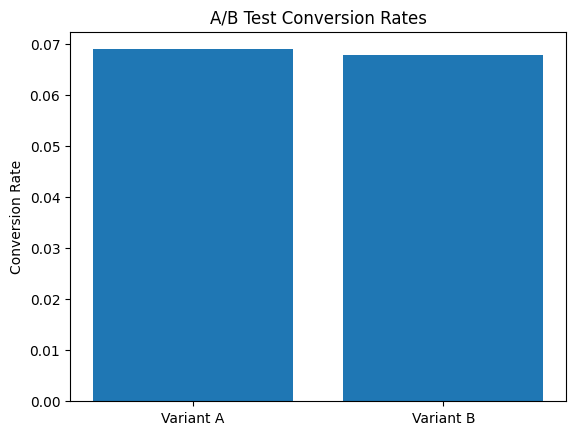

In [53]:
import matplotlib.pyplot as plt

rates = [p_A, p_B]
labels = ["Variant A", "Variant B"]

plt.bar(labels, rates)
plt.ylabel("Conversion Rate")
plt.title("A/B Test Conversion Rates")

plt.show()

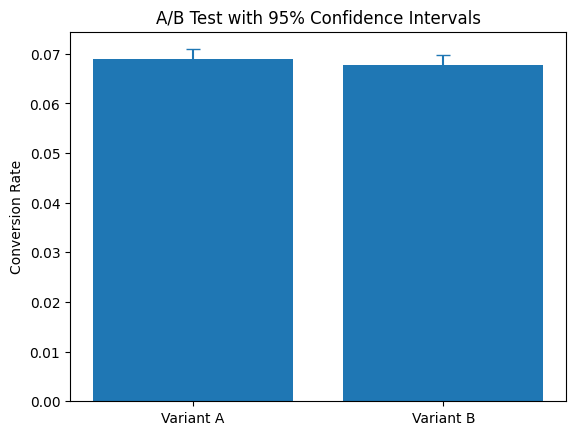

In [54]:
plt.bar(labels, rates)

plt.errorbar(
    labels,
    rates,
    yerr=[
        [p_A - ci_A[0], p_B - ci_B[0]],
        [ci_A[1] - p_A, ci_B[1] - p_B]
    ],
    fmt='none',
    capsize=5
)

plt.ylabel("Conversion Rate")
plt.title("A/B Test with 95% Confidence Intervals")

plt.show()

A/B Test Results Interpretation

Experiment Goal

Increase purchase conversion by improving the product page design.

Variants

Variant A: Current product page

Variant B: New design with improved CTA

Results

Metric	Variant A	Variant B
Conversion Rate	6.89%	6.77%

Statistical Test:

z-score: -0.79

p-value: 0.425

Conclusion

The difference between the two variants is not statistically significant (p > 0.05).

Therefore, we fail to reject the null hypothesis.

Recommendation

Do not roll out Variant B.
Further experiments should focus on improving View → Cart conversion, which is the largest drop-off in the funnel.